In [1]:
features_dir = '/Users/kesiyun/Desktop/Thesis/github/features/01SF_sw' 
extra_features_dir = '/Users/kesiyun/Desktop/Thesis/github/features/01SF_sw_aug'
split_path = '/Users/kesiyun/Desktop/Thesis/github/config/00full_video_split_5s.json'
json_path = '/Users/kesiyun/Desktop/Thesis/github/config/00sequenceresult.json'


import os
import json
import re
import glob

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset, random_split

import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np


# Utility functions
def read_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def get_training_weight(train_loader):
    def get_loader_stats(loader, name):
        weight_out=[]
        
        label_counts = {}
        feature_shapes = {}
        total_samples = 0

        for batch in loader:
            features, labels = batch
            total_samples += len(labels)

            for feature, label in zip(features, labels):
                label_val = label.item()
                label_counts[label_val] = label_counts.get(label_val, 0) + 1

                shape = tuple(feature.shape)
                feature_shapes[shape] = feature_shapes.get(shape, 0) + 1
        
        for label, count in sorted(label_counts.items()):
            weight_out.append(count)
            #print(f"    Label {label}: {count} samples")
        return weight_out
    return get_loader_stats(train_loader, "Training")    

def print_loader_metadata(train_loader, test_loader):
    def get_loader_stats(loader, name):
        label_counts = {}
        feature_shapes = {}
        total_samples = 0

        for batch in loader:
            features, labels = batch
            total_samples += len(labels)

            for feature, label in zip(features, labels):
                label_val = label.item()
                label_counts[label_val] = label_counts.get(label_val, 0) + 1

                shape = tuple(feature.shape)
                feature_shapes[shape] = feature_shapes.get(shape, 0) + 1

        print(f"\n{name} Loader:")
        print(f"  Total samples: {total_samples}")
        print(f"  Total batches (batch_size={loader.batch_size}): {len(loader)}")
        print(f"  Feature shape(s):")
        for shape, count in feature_shapes.items():
            print(f"    Shape {shape}: {count} samples")
        print(f"  Label distribution:")
        for label, count in sorted(label_counts.items()):
            print(f"    Label {label}: {count} samples")

    get_loader_stats(train_loader, "Training")
    get_loader_stats(test_loader, "Testing")

def get_final_D_cutoff_seconds(meta_for_video):
    """
    Parse the final D(mm:ss) from the 'timesec' string.
    Returns the cutoff in integer seconds, or None if there is no D.
    """
    if not meta_for_video:
        return None
    ts = meta_for_video.get('timesec', '')
    # Find ALL occurrences of D(mm:ss); use the last one as the cutoff.
    matches = list(re.finditer(r'D\((\d+):(\d+)\)', ts))
    if not matches:
        return None
    m = matches[-1]
    minutes = int(m.group(1))
    seconds = int(m.group(2))
    return minutes * 60 + seconds  # total seconds


def parse_augmented_filename(fname):
    """
    Parse names like '99A_0056_X.pt' into (base_id, timestamp_seconds, tag_suffix).
    - If timestamp token is 4 digits, interpret as MMSS.
    - Else if it's an integer string, interpret as total seconds.
    Returns (base_id, timestamp_seconds or None, tag_suffix or None).
    """
    stem = os.path.splitext(os.path.basename(fname))[0]  # e.g., '99A_0056_X'
    parts = stem.split('_')
    base = parts[0] if parts else None
    ts_seconds = None
    tag = parts[-1] if len(parts) >= 3 else (parts[1] if len(parts) == 2 else None)

    if len(parts) >= 2:
        ts_token = parts[1]
        if ts_token.isdigit():
            if len(ts_token) == 4:        # MMSS
                mm = int(ts_token[:2])
                ss = int(ts_token[2:])
                ts_seconds = mm * 60 + ss
            else:                          # total seconds
                ts_seconds = int(ts_token)

    return base, ts_seconds, tag


In [3]:
#prepare the data


#features_dir = ''
#split_path = ''



loaded_result=read_json(json_path)
dataset_split=read_json(split_path)

training_split=dataset_split['training_set']
test_split=dataset_split['testing_set']
#print(training_split)
#print(test_split)

train_features = []
train_labels = []

for video_name in training_split:
    feature_list_load_1 = torch.load(os.path.join(features_dir, video_name + '.pt'))
    # Determine cutoff (in seconds) from sequenceresult metadata
    cutoff_seconds = get_final_D_cutoff_seconds(loaded_result.get(video_name))

    for i in range(len(feature_list_load_1)):
        feature_this = feature_list_load_1[i][0]  # shape: [1, 2304]
        label_this   = feature_list_load_1[i][1]  # integer 0/1

        if cutoff_seconds is not None:
            # Each entry represents one second; i is 0-based, so second_index = i + 1
            second_index = i + 1
            # After the cutoff second, labels must be 0:
            if second_index > cutoff_seconds:
                label_this = 0

        train_features.append(feature_this)
        train_labels.append(label_this)

    print(video_name, 'added to training (cutoff:', cutoff_seconds, ')')

X_train = torch.cat(train_features, dim=0)              # [num_samples, 2304]
y_train = torch.tensor(train_labels).float().unsqueeze(1)  # [num_samples, 1]

# -------------------------
# Build TEST tensors
# -------------------------
test_features = []
test_labels   = []
skip_test=[]
#skip_test = ['16A']
 
for video_name in test_split:
    if video_name in skip_test: continue
    feature_list_load_1 = torch.load(os.path.join(features_dir, video_name + '.pt'))
    cutoff_seconds = get_final_D_cutoff_seconds(loaded_result.get(video_name))

    for i in range(len(feature_list_load_1)):
        feature_this = feature_list_load_1[i][0]  # shape: [1, 2304]
        label_this   = feature_list_load_1[i][1]  # integer 0/1

        if cutoff_seconds is not None:
            second_index = i + 1
            if second_index > cutoff_seconds:
                label_this = 0

        test_features.append(feature_this)
        test_labels.append(label_this)

    print(video_name, 'added to testing (cutoff:', cutoff_seconds, ')')

X_test = torch.cat(test_features, dim=0)              # [num_samples, 2304]
y_test = torch.tensor(test_labels).float().unsqueeze(1)  # [num_samples, 1]


1A added to training (cutoff: 265 )
1B added to training (cutoff: 245 )
1C added to training (cutoff: 585 )
1D added to training (cutoff: 508 )
1E added to training (cutoff: 215 )
1F added to training (cutoff: 200 )
2A added to training (cutoff: 905 )
3A added to training (cutoff: 178 )
3B added to training (cutoff: None )
3C added to training (cutoff: 305 )
3D added to training (cutoff: 893 )
4B added to training (cutoff: None )
4D added to training (cutoff: 746 )
4F added to training (cutoff: 74 )
5A added to training (cutoff: None )
6A added to training (cutoff: None )
6B added to training (cutoff: 240 )
6C added to training (cutoff: None )
6D added to training (cutoff: 200 )
7A added to training (cutoff: None )
8A added to training (cutoff: None )
8B added to training (cutoff: None )
9A added to training (cutoff: None )
10A added to training (cutoff: None )
10B added to training (cutoff: None )
10C added to training (cutoff: 350 )
11A added to training (cutoff: None )
11B added to 

In [4]:
#aug_

import os
import glob
import torch

# Existing training tensors (already built)
# X_train: [N, 2304]
# y_train: [N, 1]
cutoff_map = {vid: get_final_D_cutoff_seconds(meta) for vid, meta in loaded_result.items()}

#extra_features_dir = ''

extra_features = []
extra_labels = []

# Keep your suffix skip list (using just the single-letter tag before .pt)
skip_tags = {}
skip_tags = {'W', 'X', 'Y', 'Z'}



for pt_path in glob.glob(os.path.join(extra_features_dir, '*.pt')):
    base_id, ts_seconds, tag = parse_augmented_filename(pt_path)

    # Skip based on tag suffix
    if tag and tag in skip_tags:
        print(os.path.basename(pt_path), f'skipped due to suffix tag {tag}')
        continue

    # Lookup cutoff for the base video
    cutoff_seconds = cutoff_map.get(base_id)

    # If we have both a cutoff and a timestamp, enforce: only include files at or before cutoff
    if cutoff_seconds is not None and ts_seconds is not None and ts_seconds > cutoff_seconds:
        print(os.path.basename(pt_path),
              f'skipped: timestamp {ts_seconds}s exceeds cutoff {cutoff_seconds}s for {base_id}')
        continue

    # Load and append contents
    feature_list = torch.load(pt_path)
    for feat, lab in feature_list:
        # Sanity checks
        assert isinstance(lab, int), f"Label must be int, got {type(lab)} in {pt_path}"
        assert tuple(feat.shape) == (1, 2304), f"Feature shape mismatch in {pt_path}: {feat.shape}"

        extra_features.append(feat)
        extra_labels.append(lab)

    # Informative print
    if cutoff_seconds is None:
        print(os.path.basename(pt_path), f'added to training (augmented) [no cutoff for {base_id}]')
    elif ts_seconds is None:
        print(os.path.basename(pt_path), f'added to training (augmented) [timestamp missing, cutoff {cutoff_seconds}s]')
    else:
        print(os.path.basename(pt_path), f'added to training (augmented) [ts={ts_seconds}s <= cutoff {cutoff_seconds}s]')

# Convert and concatenate to existing training tensors
X_extra = torch.cat(extra_features, dim=0)                              # [N_extra, 2304]
y_extra = torch.tensor(extra_labels, dtype=torch.float32).unsqueeze(1)  # [N_extra, 1]

X_train = torch.cat([X_train, X_extra], dim=0)
y_train = torch.cat([y_train, y_extra], dim=0)


11B_0105_E.pt added to training (augmented) [ts=65s <= cutoff 76s]
13A_1050_F.pt added to training (augmented) [no cutoff for 13A]
11C_0358_D.pt added to training (augmented) [no cutoff for 11C]
10A_0456_E.pt added to training (augmented) [no cutoff for 10A]
1F_0121_C.pt added to training (augmented) [ts=81s <= cutoff 200s]
4B_0113_G.pt added to training (augmented) [no cutoff for 4B]
17G_0038_C.pt added to training (augmented) [ts=38s <= cutoff 156s]
9A_2952_E.pt added to training (augmented) [no cutoff for 9A]
18A_0120_B.pt added to training (augmented) [ts=80s <= cutoff 839s]
15A_1244_C.pt added to training (augmented) [ts=764s <= cutoff 818s]
17B_0006_H.pt added to training (augmented) [ts=6s <= cutoff 61s]
13A_1328_H.pt added to training (augmented) [no cutoff for 13A]
9A_2655_C.pt added to training (augmented) [no cutoff for 9A]
3B_0047_C.pt added to training (augmented) [no cutoff for 3B]
1C_0550_E.pt added to training (augmented) [ts=350s <= cutoff 585s]
9A_1703_D.pt added to t

In [5]:
#Used in Original, weighted loss
# Set a fixed random seed
seed = 3407
generator = torch.Generator().manual_seed(seed)

# ----- Virtual Split from Training Data -----
train_size = int(0.8 * len(X_train))
val_size = len(X_train) - train_size
train_dataset, val_dataset = random_split(
    TensorDataset(X_train, y_train),
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

print_loader_metadata(train_loader, test_loader)

import random
import numpy as np
import torch





Training Loader:
  Total samples: 30976
  Total batches (batch_size=32): 968
  Feature shape(s):
    Shape (2304,): 30976 samples
  Label distribution:
    Label 0.0: 28151 samples
    Label 1.0: 2825 samples

Testing Loader:
  Total samples: 8172
  Total batches (batch_size=32): 256
  Feature shape(s):
    Shape (2304,): 8172 samples
  Label distribution:
    Label 0.0: 8058 samples
    Label 1.0: 114 samples


Epoch 1, Train Loss: 1.0121, Val Loss: 0.9313, Val F1 (class 1): 0.3868
Epoch 2, Train Loss: 0.9173, Val Loss: 0.8885, Val F1 (class 1): 0.4207
Epoch 3, Train Loss: 0.8873, Val Loss: 0.8591, Val F1 (class 1): 0.4220
Epoch 4, Train Loss: 0.8712, Val Loss: 0.8433, Val F1 (class 1): 0.4481
Epoch 5, Train Loss: 0.8612, Val Loss: 0.8324, Val F1 (class 1): 0.4349
Epoch 6, Train Loss: 0.8554, Val Loss: 0.8292, Val F1 (class 1): 0.4286
Epoch 7, Train Loss: 0.8506, Val Loss: 0.8234, Val F1 (class 1): 0.4425
Epoch 8, Train Loss: 0.8474, Val Loss: 0.8193, Val F1 (class 1): 0.4329
Epoch 9, Train Loss: 0.8442, Val Loss: 0.8140, Val F1 (class 1): 0.4381
Epoch 10, Train Loss: 0.8419, Val Loss: 0.8188, Val F1 (class 1): 0.4023
Epoch 11, Train Loss: 0.8387, Val Loss: 0.8146, Val F1 (class 1): 0.4095
Epoch 12, Train Loss: 0.8373, Val Loss: 0.8091, Val F1 (class 1): 0.4428
Epoch 13, Train Loss: 0.8344, Val Loss: 0.8081, Val F1 (class 1): 0.4558
Epoch 14, Train Loss: 0.8325, Val Loss: 0.8150, Val F1 (clas

/var/folders/dn/8xt3xqsn3ysf586z6l0zvfym0000gn/T/ipykernel_71148/2092729286.py:242: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  all_preds = torch.tensor(all_preds).view(-1).numpy()



--- Detailed Evaluation on Test Set ---
True Positives (C): 45
False Positives (C): 585
False Negatives (C): 69
Precision (C): 0.0714
Recall (C): 0.3947
F1 Score (C): 0.1210
Accuracy: 0.9200
Macro Precision: 0.5311
Macro F1: 0.5395


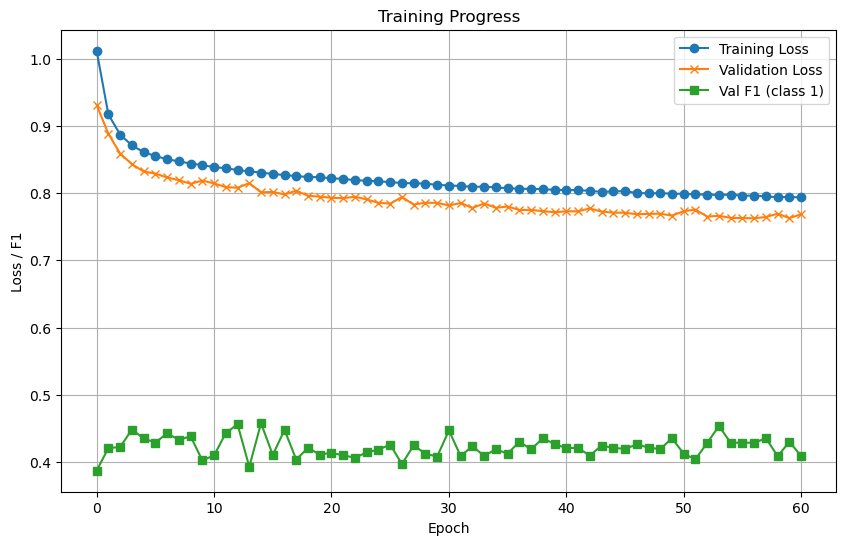

In [6]:

# -----------------------------
# Reproducibility (unchanged)
# -----------------------------
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

seed = 3407
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Pathway slicing configuration
# -----------------------------
TOTAL_DIM = 2304           # Your full feature length
FAST_DIM = 256             # Fast pathway size
# If your slow really is 2408, set SLOW_DIM = 2408 and ensure TOTAL_DIM matches.
SLOW_DIM = TOTAL_DIM - FAST_DIM  # Typically 2048 if TOTAL_DIM=2304

SELECT_PATHWAY = "fast"    # Options: 'fast', 'slow', 'custom'
THRESHOLD = 0.5            # Default threshold, you can tune later if desired

# For 'custom' slicing, define indices:
CUSTOM_START = 0
CUSTOM_END = TOTAL_DIM     # Python slice end is exclusive

def get_feature_slice(total_dim=TOTAL_DIM, fast_dim=FAST_DIM, slow_dim=SLOW_DIM):
    if SELECT_PATHWAY == "fast":
        # Last FAST_DIM channels
        return slice(total_dim - fast_dim, total_dim)
    elif SELECT_PATHWAY == "slow":
        # First SLOW_DIM channels (change slow_dim if yours is 2408)
        return slice(0, slow_dim)
    elif SELECT_PATHWAY == "custom":
        return slice(CUSTOM_START, CUSTOM_END)
    else:
        raise ValueError("SELECT_PATHWAY must be 'fast', 'slow', or 'custom'.")

feature_slice = get_feature_slice()

# -----------------------------
# Dataset wrapper for slicing
# -----------------------------
class SlicedTensorDataset(Dataset):
    def __init__(self, X, y, feature_slice):
        # Ensure labels are shape (N,1) float for BCEWithLogitsLoss
        if y.dim() == 1:
            y = y.view(-1, 1)
        elif y.dim() == 2 and y.shape[1] != 1:
            raise ValueError("Expected labels with shape (N,) or (N,1).")
        self.X = X[:, feature_slice].contiguous()
        self.y = y.float().contiguous()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -----------------------------
# Virtual split (unchanged logic)
# -----------------------------
generator = torch.Generator().manual_seed(seed)
train_size = int(0.8 * len(X_train))
val_size = len(X_train) - train_size

full_train_ds = SlicedTensorDataset(X_train, y_train, feature_slice)
train_dataset, val_dataset = random_split(full_train_ds, [train_size, val_size], generator=generator)

test_dataset = SlicedTensorDataset(X_test, y_test, feature_slice)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# (Optional) Your existing metadata function
# print_loader_metadata(train_loader, test_loader)

# -----------------------------
# Model (returns logits now)
# -----------------------------
class LinearClassifierLogits(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)  # logits

    def forward(self, x):
        return self.linear(x)  # no sigmoid here

input_dim = full_train_ds.X.shape[1]  # e.g., 256 when 'fast'
model = LinearClassifierLogits(input_dim=input_dim).to(device)

# -----------------------------
# Weighted loss for imbalance
# -----------------------------
# Compute pos_weight = (neg_count / pos_count) from the *sliced* training subset
with torch.no_grad():
    # Grab the labels from the underlying Subset
    y_all = []
    for _, labels in DataLoader(train_dataset, batch_size=4096):
        y_all.append(labels)
    y_all = torch.cat(y_all, dim=0).to(device)
    pos_count = (y_all == 1).sum().item()
    neg_count = (y_all == 0).sum().item()
    # Avoid divide-by-zero
    pos_weight_value = (neg_count / max(1, pos_count)) if pos_count > 0 else 1.0

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -----------------------------
# Training (preserved structure)
# -----------------------------
train_losses = []
val_losses = []
val_f1_scores = []

force_epoch=61  #0 #3 #61 #116 #274

manual_patience = 50
best_val_f1 = 0.0
epochs_no_improve = 0
max_epochs = 500
demonstrate_early_stopping = False

best_model_state = None
best_epoch = 0

for epoch in range(max_epochs):
    # ---- Train ----
    model.train()
    total_loss = 0.0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(features)                 # (B,1)
        loss = criterion(logits, labels)         # ??? BCEWithLogitsLoss???
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            val_logits = model(val_features)
            val_loss += criterion(val_logits, val_labels).item()
            val_probs = torch.sigmoid(val_logits)
            val_pred = (val_probs > THRESHOLD).float().cpu().numpy()
            val_target = val_labels.cpu().numpy()
            val_preds.extend(val_pred)
            val_targets.extend(val_target)

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_f1_C = f1_score(np.array(val_targets).reshape(-1), np.array(val_preds).reshape(-1), pos_label=1)
    val_f1_scores.append(val_f1_C)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1 (class 1): {val_f1_C:.4f}")

    # ---- Early stopping on class-1 F1 (preserved) ----
    if val_f1_C > best_val_f1 and force_epoch==0:
        best_val_f1 = val_f1_C
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_no_improve = 0
    elif(val_f1_C <= best_val_f1 and force_epoch==0):
        epochs_no_improve += 1
        if (epochs_no_improve >= manual_patience):
            print(f"Early stopping triggered at epoch {epoch+1} based on F1-score of class 1, using best model from epoch {best_epoch+1}.")
            if not demonstrate_early_stopping:
                break
            if val_f1_C < 0.8 * best_val_f1:
                print("Validation F1-score dropped significantly. Stopping training.")
                break
    elif (force_epoch>0):
        best_val_f1 = val_f1_C
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_no_improve = 0
        if  (epoch+1 >= force_epoch):
            print(f"Stopped at using model from epoch {epoch+1}.")
            break
        

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# -----------------------------
# Plot (preserved)
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
plt.plot(val_f1_scores, label='Val F1 (class 1)', marker='s')
if demonstrate_early_stopping:
    plt.axvline(x=best_epoch, color='r', linestyle='--', label='Early Stop Point')
plt.title('Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss / F1')
plt.legend()
plt.grid(True)
plt.savefig("loss_curves.png")

# -----------------------------
# Final Test Evaluation (preserved metrics)
# -----------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        logits = model(features)
        probs = torch.sigmoid(logits)
        preds = (probs > THRESHOLD).float().cpu()   # (B,1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Flatten to 1D
all_preds = torch.tensor(all_preds).view(-1).numpy()
all_labels = torch.tensor(all_labels).view(-1).numpy()

# Manual counts for class 1 ('C')
TP_c = ((all_preds == 1) & (all_labels == 1)).sum()
FN_c = ((all_preds == 0) & (all_labels == 1)).sum()
FP_c = ((all_preds == 1) & (all_labels == 0)).sum()

# Metrics (preserved)
precision_C = precision_score(all_labels, all_preds, pos_label=1)
recall_C = recall_score(all_labels, all_preds, pos_label=1)
f1_C = f1_score(all_labels, all_preds, pos_label=1)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n--- Detailed Evaluation on Test Set ---")
print(f"True Positives (C): {TP_c}")
print(f"False Positives (C): {FP_c}")
print(f"False Negatives (C): {FN_c}")
print(f"Precision (C): {precision_C:.4f}")
print(f"Recall (C): {recall_C:.4f}")
print(f"F1 Score (C): {f1_C:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
